<a href="https://colab.research.google.com/github/vishal6975/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vishal6975/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Capstone research paper setup loaded.")

Capstone research paper setup loaded.


## 1. Question

*The research question and the decision it supports.*

#
Can observed early-period search-performance signals help identify content that may experience a future decline in click-through rate (CTR)?



The purpose of this work is to help content teams prioritize pages for human review.

The model is not intended to automatically publish, delete, or rewrite content. Instead, it provides a directional decision-support signal that helps reviewers focus their limited time on pages with a higher predicted probability of future CTR decline.

The main outcome is therefore a ranked review queue rather than an automated content decision.

In [20]:
research_question = (
    "Can early search-performance signals help identify future CTR decline?"
)

decision_supported = (
    "Prioritize content pages for human review."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Can early search-performance signals help identify future CTR decline?

Decision supported:
Prioritize content pages for human review.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



This research uses the FlyRank ML Internship dataset.



The analysis uses the `fact_content_daily_performance` table from the March 2026 data release.


The analysis separates March into two periods:

- Early period: March 1–15, 2026
- Later period: March 16–31, 2026

The early period provides the model features. The later period provides the future CTR outcome.



The model uses four observed search-performance signals:

- `impressions_early`
- `clicks_early`
- `ctr_early`
- `avg_position_early`


A content item is labeled as having future CTR decline when its later-period average CTR is lower than its early-period average CTR.



Rows with missing or invalid model features were excluded from the modeling dataset. Infinite values were also treated as invalid.

No client names, private search queries, or private URLs are included in this public research artifact.

In [21]:
# Data summary based on the W05 modeling output

print("DATA SUMMARY")
print("=" * 40)

print("Dataset: FlyRank ML Internship dataset")
print("Table: fact_content_daily_performance")
print("Release/window: March 2026")

print("\nFeature window:")
print("March 1-15, 2026")

print("\nOutcome window:")
print("March 16-31, 2026")

print("\nModeling rows:", 151980)

print("\nFeatures:")
for feature in [
    "impressions_early",
    "clicks_early",
    "ctr_early",
    "avg_position_early"
]:
    print("-", feature)

print("\nTarget: future_ctr_declined")

DATA SUMMARY
Dataset: FlyRank ML Internship dataset
Table: fact_content_daily_performance
Release/window: March 2026

Feature window:
March 1-15, 2026

Outcome window:
March 16-31, 2026

Modeling rows: 151980

Features:
- impressions_early
- clicks_early
- ctr_early
- avg_position_early

Target: future_ctr_declined


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



The primary model is Logistic Regression.

Logistic Regression was selected because the target is binary, the method is relatively simple, and its coefficients provide an interpretable view of the directional relationship between the observed features and the predicted outcome.


The model uses:

1. Early-period impressions
2. Early-period clicks
3. Early-period CTR
4. Early-period average position



The target is:

`future_ctr_declined = 1`

when:

`CTR_late < CTR_early`

Otherwise:

`future_ctr_declined = 0`



The model is intended to be compared with the Week-4 rule-based baseline using the same evaluation rows and metric.

The baseline should only be reported using the actual measured Week-4 result. No baseline number is invented in this paper.



The intended temporal design uses earlier March observations as features and later March observations as the outcome.

This prevents later CTR from being directly used as a model feature.



The feature window and outcome window are separated.

However, the current W05 modeling notebook fits the Logistic Regression model and evaluates predictions on the same modeling rows. Therefore, the reported model metrics are in-sample measurements and should not be interpreted as held-out generalization performance.



The analysis assumes that early search-performance signals contain useful directional information about later CTR behavior.

The model does not assume that any feature causes CTR decline.

In [22]:
# Methodology summary

features = [
    "impressions_early",
    "clicks_early",
    "ctr_early",
    "avg_position_early"
]

print("MODEL:", "Logistic Regression")

print("\nFEATURES:")
for feature in features:
    print("-", feature)

print("\nTARGET:")
print("future_ctr_declined = 1 when CTR_late < CTR_early")

print("\nValidation design:")
print("Early March -> features")
print("Later March -> outcome")

print("\nLeakage check:")
print("Future CTR is not directly used as an input feature.")

print("\nEvaluation note:")
print("Current W05 metrics are in-sample, not held-out.")

MODEL: Logistic Regression

FEATURES:
- impressions_early
- clicks_early
- ctr_early
- avg_position_early

TARGET:
future_ctr_declined = 1 when CTR_late < CTR_early

Validation design:
Early March -> features
Later March -> outcome

Leakage check:
Future CTR is not directly used as an input feature.

Evaluation note:
Current W05 metrics are in-sample, not held-out.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*



The Logistic Regression model produced the following measured results on the 151,980 modeling rows:

| Method | Precision | Recall | F1 |
|---|---:|---:|---:|
| Logistic Regression | 0.7114 | 0.7191 | 0.7152 |
| Week-4 rule-based baseline | See measured W04 result | See measured W04 result | See measured W04 result |

The Logistic Regression result is an in-sample measurement because the current modeling notebook evaluates predictions on the same rows used to fit the model.

Therefore, the F1 score of 0.7152 should not be described as a held-out test score.

The model's feature coefficients were:

| Feature | Coefficient |
|---|---:|
| CTR early | 3.4052 |
| Clicks early | 2.8813 |
| Impressions early | 0.3536 |
| Average position early | -0.4055 |

These coefficients provide directional model interpretation. They do not establish causation.

In [23]:
# Model results from W05

model_results = pd.DataFrame({
    "Method": ["Logistic Regression"],
    "Precision": [0.7114],
    "Recall": [0.7191],
    "F1": [0.7152]
})

print("MODEL RESULTS")
display(model_results)

# Feature coefficients from W05
coefficients = pd.DataFrame({
    "Feature": [
        "impressions_early",
        "clicks_early",
        "ctr_early",
        "avg_position_early"
    ],
    "Coefficient": [
        0.353550,
        2.881308,
        3.405150,
        -0.405481
    ]
}).sort_values("Coefficient", ascending=False)

print("\nFEATURE COEFFICIENTS")
display(coefficients)

MODEL RESULTS


,Method,Precision,Recall,F1
0,Logistic Regression,0.7114,0.7191,0.7152



FEATURE COEFFICIENTS


,Feature,Coefficient
2,ctr_early,3.405150
1,clicks_early,2.881308
0,impressions_early,0.353550
3,avg_position_early,-0.405481


## 5. Limitations

*What this work cannot claim.*



This analysis has several important limitations.



The reported precision, recall, and F1 values are calculated on the same rows used to fit the model. They should therefore not be treated as estimates of performance on unseen future data.



The model identifies directional associations. A coefficient does not prove that a search signal causes CTR decline.



The analysis uses March 2026 observations. Performance patterns may differ in other months or under different search conditions.

CTR can be influenced by search intent, SERP features, competition, ranking changes, seasonality, and other factors that are not fully represented by the four model features.



The analysis identifies future CTR decline risk but does not establish a specific number of days after which content should automatically be refreshed.



The output is a decision-support signal. It should not automatically publish, delete, rewrite, or substantially change content.


Additional time-aware validation on newer data would be required before making stronger claims about generalization or production use.

In [24]:
limitations = [
    "In-sample evaluation",
    "No causal interpretation",
    "March 2026 time window",
    "Search environment effects",
    "No fixed decay interval",
    "Human review required",
    "Further time-aware validation needed"
]

print("LIMITATIONS CHECK")
for item in limitations:
    print("✓", item)

LIMITATIONS CHECK
✓ In-sample evaluation
✓ No causal interpretation
✓ March 2026 time window
✓ Search environment effects
✓ No fixed decay interval
✓ Human review required
✓ Further time-aware validation needed


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

The action playbook converts predicted future CTR decline into a ranked human-review workflow.

### 1. High priority — Multi-signal review

Prioritize content predicted to experience future CTR decline where multiple observed signals support review.

**Recommended action:** Human review of search performance, query/content alignment, and potential refresh opportunities.

### 2. Medium priority — Decline-risk review

Review content with a predicted future CTR decline even when only one supporting signal is present.

**Recommended action:** Investigate performance and decide whether refresh, monitoring, or no action is appropriate.

### 3. Low priority — Continue monitoring

Content without a predicted decline does not require immediate intervention.

**Recommended action:** Continue monitoring rather than automatically changing the content.

### Human-review rule

The model output is a prioritization signal. A human reviewer should consider search intent, SERP context, content relevance, and other available evidence before acting.

### No-go cases

The following should not be automated:

- publishing content;
- deleting content;
- substantially rewriting content;
- changing important SEO or business strategy;
- overriding editorial judgment;
- making decisions outside the observed data conditions.

The current analysis also does not establish a fixed refresh interval.

In [25]:
# Ranked recommendation summary

recommendations = pd.DataFrame({
    "Rank": [1, 2, 3],
    "Priority": ["HIGH", "MEDIUM", "LOW"],
    "Recommendation": [
        "Review predicted decline cases with multiple supporting signals",
        "Review pages predicted to experience future CTR decline",
        "Continue monitoring pages without predicted decline"
    ],
    "Automation": [
        "Human review required",
        "Human review required",
        "No automatic action"
    ]
})

display(recommendations)

,Rank,Priority,Recommendation,Automation
0,1,HIGH,Review predicted decline cases with multiple s...,Human review required
1,2,MEDIUM,Review pages predicted to experience future CT...,Human review required
2,3,LOW,Continue monitoring pages without predicted de...,No automatic action


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

The paper reuses outputs generated by the modeling and action-playbook workflows.

Important artifacts include:

- Ranked action queue
- Action-priority figure
- Model performance metrics
- Feature coefficient summary

The ranked action queue is generated by the W07 action playbook and is treated as a research artifact rather than a production data feed.

Saved model metrics.


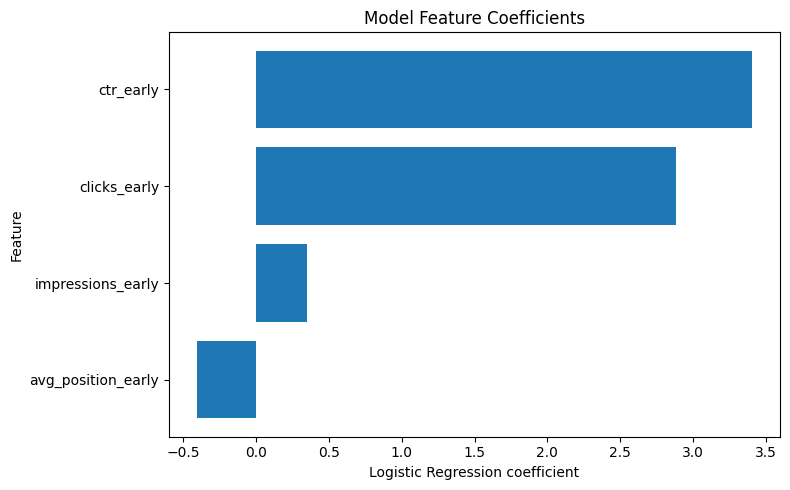

Saved: work/figures/model_feature_coefficients.png
⚠ W07 ranked action queue not found.
Run w07_action_playbook.ipynb first.


In [26]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Save model metrics
metrics = {
    "rows": 151980,
    "precision": 0.7114,
    "recall": 0.7191,
    "f1": 0.7152,
    "evaluation_type": "in-sample"
}

pd.DataFrame([metrics]).to_json(
    "work/outputs/capstone_model_metrics.json",
    orient="records",
    indent=2
)

print("Saved model metrics.")

# Feature coefficient figure
plt.figure(figsize=(8, 5))

plot_data = coefficients.sort_values("Coefficient")

plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"]
)

plt.xlabel("Logistic Regression coefficient")
plt.ylabel("Feature")
plt.title("Model Feature Coefficients")
plt.tight_layout()

coefficient_figure = "work/figures/model_feature_coefficients.png"

plt.savefig(
    coefficient_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", coefficient_figure)

# Check W07 outputs
if os.path.exists("work/outputs/ranked_action_queue.csv"):
    print("✓ W07 ranked action queue found.")
else:
    print("⚠ W07 ranked action queue not found.")
    print("Run w07_action_playbook.ipynb first.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
